In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

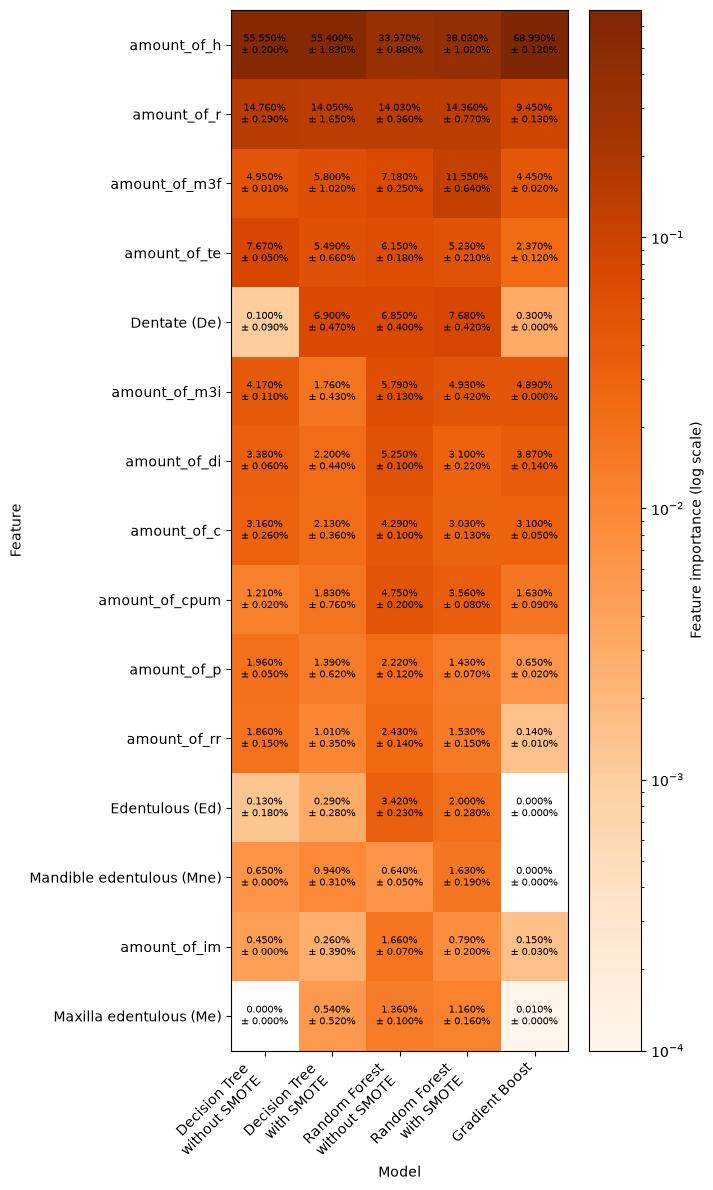

In [ ]:
# ============================================================
# Dados
# ============================================================

features = [
    "amount_of_h",
    "amount_of_r",
    "amount_of_te",
    "amount_of_m3f",
    "amount_of_m3i",
    "amount_of_di",
    "amount_of_c",
    "amount_of_p",
    "amount_of_rr",
    "amount_of_cpum",
    "mouth_condition_Mandible edentulous (Mne)",
    "amount_of_im",
    "mouth_condition_Edentulous (Ed)",
    "mouth_condition_Dentate (De)",
    "mouth_condition_Maxilla edentulous (Me)",
]

data = {
    "Decision Tree\nwithout SMOTE": [
        (0.5555, 0.0020),
        (0.1476, 0.0029),
        (0.0767, 0.0005),
        (0.0495, 0.0001),
        (0.0417, 0.0011),
        (0.0338, 0.0006),
        (0.0316, 0.0026),
        (0.0196, 0.0005),
        (0.0186, 0.0015),
        (0.0121, 0.0002),
        (0.0065, 0.0000),
        (0.0045, 0.0000),
        (0.0013, 0.0018),
        (0.0010, 0.0009),
        (0.0000, 0.0000),
    ],
    "Decision Tree\nwith SMOTE": [
        (0.5540, 0.0183),
        (0.1405, 0.0165),
        (0.0549, 0.0066),
        (0.0580, 0.0102),
        (0.0176, 0.0043),
        (0.0220, 0.0044),
        (0.0213, 0.0036),
        (0.0139, 0.0062),
        (0.0101, 0.0035),
        (0.0183, 0.0076),
        (0.0094, 0.0031),
        (0.0026, 0.0039),
        (0.0029, 0.0028),
        (0.0690, 0.0047),
        (0.0054, 0.0052),
    ],
    "Random Forest\nwithout SMOTE": [
        (0.3397, 0.0088),
        (0.1403, 0.0036),
        (0.0615, 0.0018),
        (0.0718, 0.0025),
        (0.0579, 0.0013),
        (0.0525, 0.0010),
        (0.0429, 0.0010),
        (0.0222, 0.0012),
        (0.0243, 0.0014),
        (0.0475, 0.0020),
        (0.0064, 0.0005),
        (0.0166, 0.0007),
        (0.0342, 0.0023),
        (0.0685, 0.0040),
        (0.0136, 0.0010),
    ],
    "Random Forest\nwith SMOTE": [
        (0.3803, 0.0102),
        (0.1436, 0.0077),
        (0.0523, 0.0021),
        (0.1155, 0.0064),
        (0.0493, 0.0042),
        (0.0310, 0.0022),
        (0.0303, 0.0013),
        (0.0143, 0.0007),
        (0.0153, 0.0015),
        (0.0356, 0.0008),
        (0.0163, 0.0019),
        (0.0079, 0.0020),
        (0.0200, 0.0028),
        (0.0768, 0.0042),
        (0.0116, 0.0016),
    ],
    "Gradient Boost": [
        (0.6899, 0.0012),
        (0.0945, 0.0013),
        (0.0237, 0.0012),
        (0.0445, 0.0002),
        (0.0489, 0.0000),
        (0.0387, 0.0014),
        (0.0310, 0.0005),
        (0.0065, 0.0002),
        (0.0014, 0.0001),
        (0.0163, 0.0009),
        (0.0000, 0.0000),
        (0.0015, 0.0003),
        (0.0000, 0.0000),
        (0.0030, 0.0000),
        (0.0001, 0.0000),
    ],
}


# ============================================================
# Montar DataFrames
# ============================================================

importance = pd.DataFrame(
    {model: [mean for mean, std in values] for model, values in data.items()},
    index=features,
).T

std = pd.DataFrame(
    {model: [std for mean, std in values] for model, values in data.items()},
    index=features,
).T


# ============================================================
# Opcional: ordenar as features pela importância média global
# ============================================================

feature_order = importance.mean(axis=0).sort_values(ascending=False).index

importance = importance.loc[:, feature_order]
std = std.loc[:, feature_order]


# ============================================================
# Rótulos mais legíveis
# ============================================================

feature_labels = {
    "amount_of_h": "amount_of_h",
    "amount_of_r": "amount_of_r",
    "amount_of_te": "amount_of_te",
    "amount_of_m3f": "amount_of_m3f",
    "amount_of_m3i": "amount_of_m3i",
    "amount_of_di": "amount_of_di",
    "amount_of_c": "amount_of_c",
    "amount_of_p": "amount_of_p",
    "amount_of_rr": "amount_of_rr",
    "amount_of_cpum": "amount_of_cpum",
    "amount_of_im": "amount_of_im",
    "mouth_condition_Dentate (De)": "Dentate (De)",
    "mouth_condition_Edentulous (Ed)": "Edentulous (Ed)",
    "mouth_condition_Mandible edentulous (Mne)": "Mandible edentulous (Mne)",
    "mouth_condition_Maxilla edentulous (Me)": "Maxilla edentulous (Me)",
}

importance.columns = [
    feature_labels.get(feature, feature) for feature in importance.columns
]

std.columns = importance.columns


# ============================================================
# Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(7, 12))

positive_values = importance.values[importance.values > 0]

image = ax.imshow(
    importance.T.replace(0, np.nan).values,
    aspect="auto",
    interpolation="nearest",
    cmap="Oranges",
    norm=LogNorm(
        vmin=positive_values.min(),
        vmax=positive_values.max(),
    ),
)

# Eixo X = modelos
ax.set_xticks(np.arange(len(importance.index)))
ax.set_xticklabels(
    importance.index,
    rotation=45,
    ha="right",
)

# Eixo Y = features
ax.set_yticks(np.arange(len(importance.columns)))
ax.set_yticklabels(importance.columns)

# Colorbar
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Feature importance (log scale)")

# Anotações
for row in range(importance.shape[1]):
    for col in range(importance.shape[0]):
        mean = importance.iloc[col, row]
        deviation = std.iloc[col, row]

        ax.text(
            col,
            row,
            f"{mean:.3f}\n± {deviation:.3f}",
            ha="center",
            va="center",
            fontsize=7,
        )

ax.set_xlabel("Model")
ax.set_ylabel("Feature")

fig.tight_layout()
plt.show()